In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import math

In [27]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\homeprices (1).csv")

In [28]:
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


In [29]:
df.isnull().sum()

area        0
bedrooms    1
age         0
price       0
dtype: int64

In [30]:
df.bedrooms.median()

4.0

In [31]:
med = int(df.bedrooms.median())
med

4

In [32]:
df.bedrooms = df.bedrooms.fillna(med)
df

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,4.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000
5,4100,6.0,8,810000


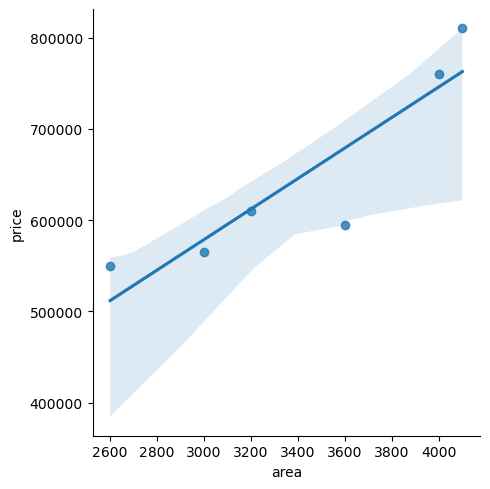

In [33]:
sns.lmplot(x='area',y='price',data=df)

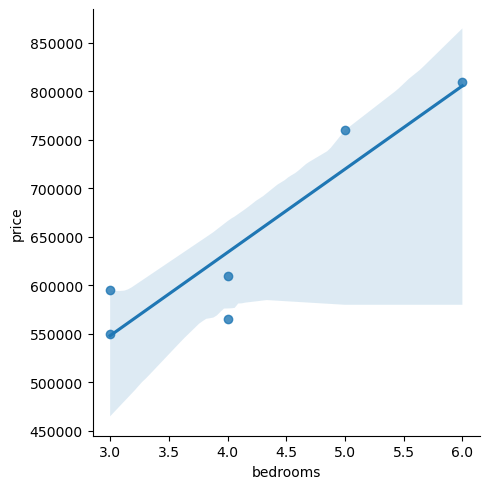

In [34]:
sns.lmplot(x='bedrooms',y='price',data=df)

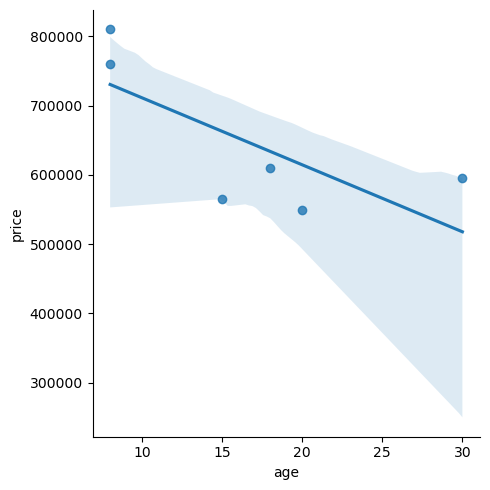

In [35]:
sns.lmplot(x='age',y='price',data=df)

In [36]:
reg = LinearRegression()

In [37]:
reg.fit(df[['area','bedrooms','age']], df['price'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
reg.coef_

array([  112.06244194, 23388.88007794, -3231.71790863])

In [39]:
reg.intercept_

np.float64(221323.00186540402)

In [40]:
reg.predict([[3000,3,40]])

C:\Users\DELL\OneDrive\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([498408.25158031])

In [ ]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load dataset
df = pd.read_csv("JaipurFinalCleanData.csv")

# Step 3: Drop non-numeric column (date)
df = df.drop(columns=["date"])

# Step 4: Handle missing values
df = df.dropna()

# Step 5: Define features and target
# Target = precipm_3 (last column in your dataset)
X = df.drop(columns=["precipm_3"])
y = df["precipm_3"]

# Step 6: Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 7: Create model
model = LinearRegression()

# Step 8: Train model
model.fit(X_train, y_train)

# Step 9: Predict
y_pred = model.predict(X_test)

# Step 10: Evaluate
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Step 11: Coefficients
coeff = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Importance:\n", coeff)